In [1]:
from src.sampling.main import stratified_spatial_kfold_dual #Dont know why but this has to be initialised first else kernel crashes

import torch
import os
import time
import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader as GeometricDataLoader

from src.performance_logger import PerformanceLogger
from models.gnn import GNNInductiveHetero
from src.utils import read_config
from src.raingauge.utils import (
  load_raingauge_dataset
)
from src.radar.utils import load_radar_dataset
from training.logic_hetero import train_epoch, validate, test_model
from src.graph.gaugegraph import GaugeGraph
from src.graph.radargraph import RadarGraph
from src.graph.gaugegraphnew import GaugeGraphNew, HeterogeneousWeatherGraphDatasetInductive

%load_ext autoreload
%autoreload 2

/opt/miniconda3/envs/fyp/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config = read_config('config.yaml')
batch_size = config['training_params']['batch_size']
fold_count = config['training_params']['fold_count']

In [3]:
experiment_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_new"
os.makedirs(f"experiments/{experiment_name}", exist_ok=True)
perf = PerformanceLogger(f"experiments/{experiment_name}/training_log.jsonl")

In [4]:
uptime_threshold = config['filters']['uptime_threshold']
start_year = config['dataset_parameters']['start_year']
end_year = config['dataset_parameters']['end_year']
raingauge_df, raingauge_station_mappings_df = load_raingauge_dataset(start = start_year, end = end_year, uptime_threshold=uptime_threshold)

Loading raingauge data from 2024 to 2025
Loading raingauge_dataset from database/raingauge_nea_data/2024/weather_station_data_2024.csv
Loading raingauge_dataset from database/raingauge_nea_data/2025/weather_station_data_2025.csv
Loading complete
Dataframe shape: (209691, 70)
Filtering raingauge_uptime. Threshold = 0.9
Getting raingauge coordinate mappings
Mapping df shape: (51, 4)


In [5]:
radar_df = load_radar_dataset(folder_name='database/sg_radar_data_cropped', cropped=True)

Loading radar TIF files from database/sg_radar_data_cropped
Radar dataset loaded!
The size of dataset is (8334, 5)


In [6]:
raingauge_df = raingauge_df.fillna(0)

In [7]:
split_info = stratified_spatial_kfold_dual(
    raingauge_station_mappings_df, seed=123, plot=False, n_splits = fold_count 
)

SPATIAL K-FOLD STRATIFIED SAMPLING (Fixed)
Total stations: 51
Clusters: 8
Folds: 2
Random seed: 123
--------------------------------------------------------------------------------
Cluster 0: 2 stations → 2 test assignments, 0 always-train
Cluster 1: 7 stations → 2 test assignments, 5 always-train
Cluster 2: 6 stations → 2 test assignments, 4 always-train
Cluster 3: 13 stations → 2 test assignments, 11 always-train
Cluster 4: 7 stations → 2 test assignments, 5 always-train
Cluster 5: 7 stations → 2 test assignments, 5 always-train
Cluster 6: 4 stations → 2 test assignments, 2 always-train
Cluster 7: 5 stations → 2 test assignments, 3 always-train

Creating Fold 1/2
Test stations: 8 (should be ~8)
Train pool: 43
Fold 1 summary:
  Statistical train: 43 (84.3%)
  Test: 8 (15.7%)
  ML train: 35 (68.6%)
  ML validation: 8 (15.7%)

Creating Fold 2/2
Test stations: 8 (should be ~8)
Train pool: 43
Fold 2 summary:
  Statistical train: 43 (84.3%)
  Test: 8 (15.7%)
  ML train: 35 (68.6%)
  ML val

# rewrite graph generation

In [8]:
gauge_graph_arr = []
for i in range(fold_count):
  gauge_graph = GaugeGraphNew(raingauge_df, raingauge_station_mappings_df, split_info = split_info[i], knn=5)
  gauge_graph_arr.append(gauge_graph)

___________________________________

/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraphnew.py:403: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


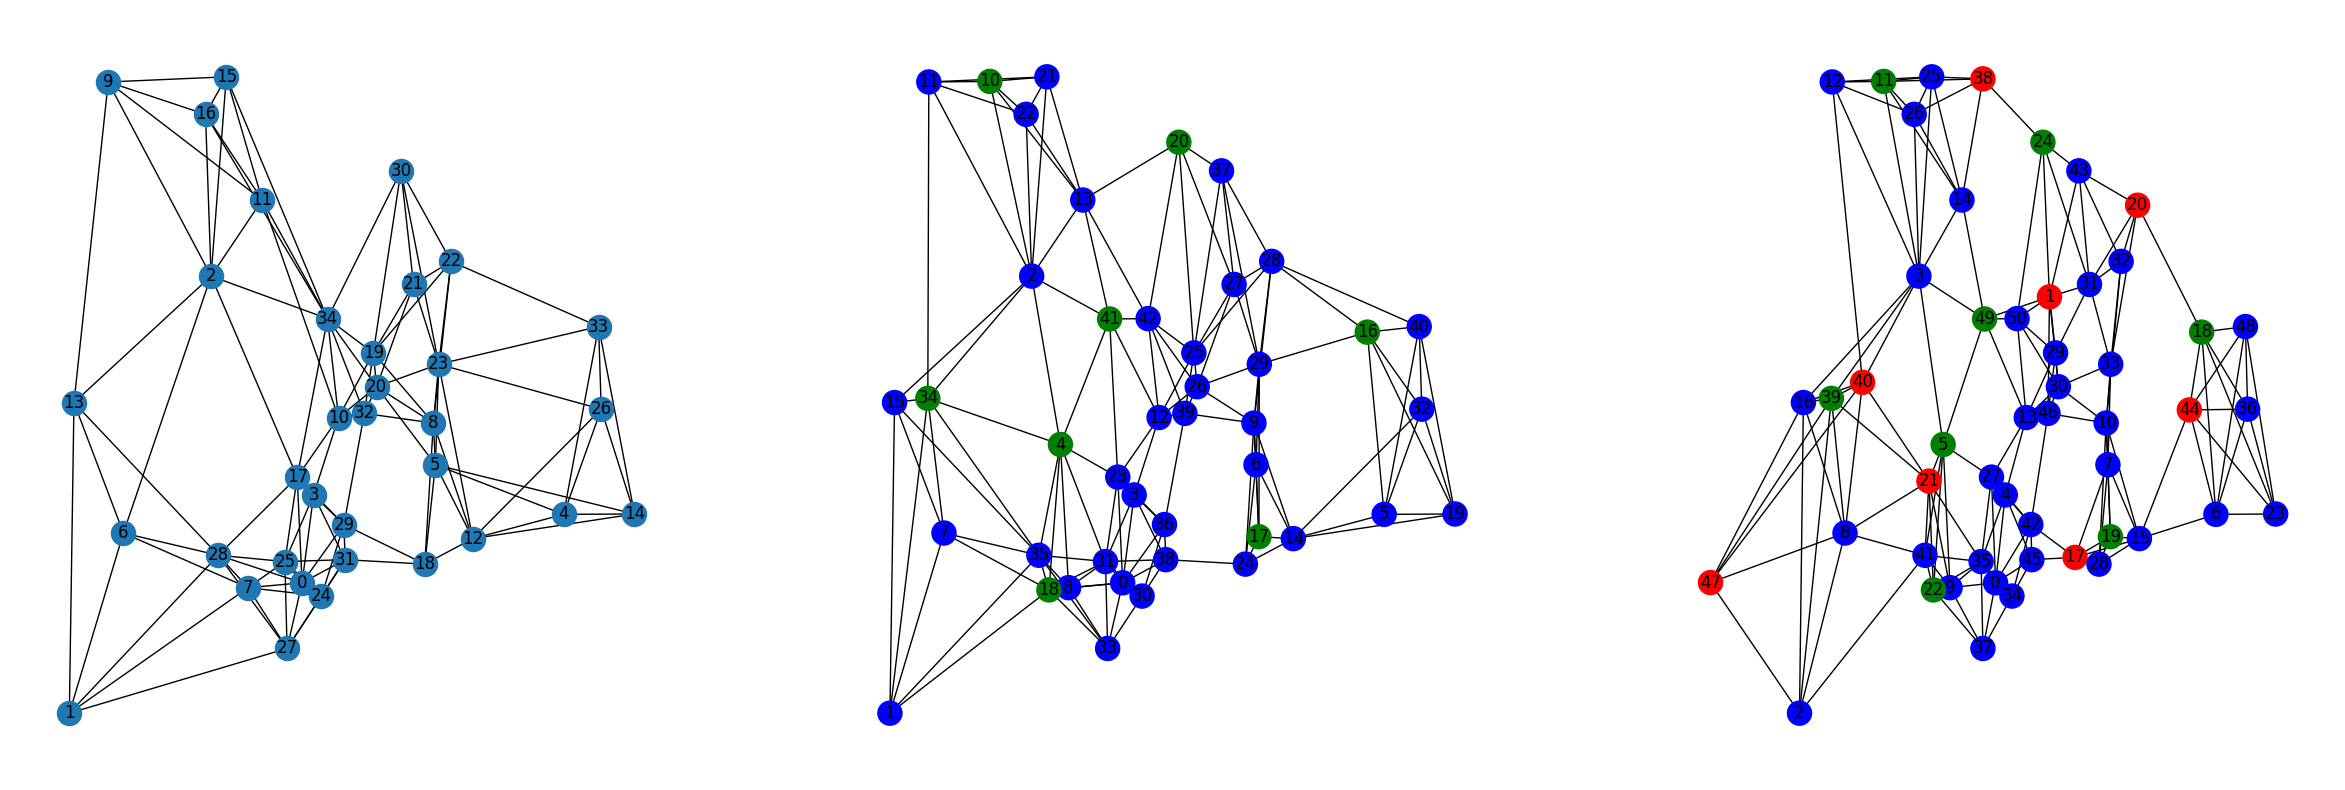

In [9]:
gauge_graph_arr[0].visualise_graph_split()

In [ ]:
hidden_channels = 8
out_channels = 1
num_layers = 8
model_arr = []
for i in range(fold_count):
  model_arr.append(
    GNNInductiveHetero(
      in_channels_dict = {
        "raingauge": 1
      },
      hidden_channels = hidden_channels,
      out_channels=out_channels, 
      num_layers = num_layers,
      edge_types=gauge_graph_arr[i].get_train_heterodata().edge_types
    ).to(device=device)
  )

In [ ]:
train_loader_arr = []
val_loader_arr = []
test_loader_arr = []
for i in range(fold_count):
    train_loader = GeometricDataLoader(
    HeterogeneousWeatherGraphDatasetInductive(gauge_graph_arr[i].get_train_heterodata()), #Need to convert to timestep wise data
    batch_size=batch_size,
    shuffle= False,
    )

    val_loader = GeometricDataLoader(
    HeterogeneousWeatherGraphDatasetInductive(gauge_graph_arr[i].get_validation_heterodata()),
    batch_size=batch_size,
    shuffle=False,
    )

    test_loader = GeometricDataLoader(
    HeterogeneousWeatherGraphDatasetInductive(gauge_graph_arr[i].get_test_heterodata()),
    batch_size = batch_size, 
    shuffle = False
    )

    train_loader_arr.append(train_loader)
    val_loader_arr.append(val_loader)
    test_loader_arr.append(test_loader)

In [ ]:
def train_fold(model, train_loader, val_loader, fold, device="cpu"):
    # CHECK 1: Print initial weights
    print("Training")
    print(f"Device type: {device}")
    first_param = next(model.parameters())
    print(f"Initial weight sample: {first_param.data.flatten()[:5]}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    training_loss_arr = []
    validation_loss_arr = []
    early = 0
    mini = 1000
    stopping_condition = 5
    epochs = 0
    total_epochs = 10
    print(f"-----FOLD: {fold}-----")
    training_start = time.time()
    for i in range(total_epochs):
        epoch_start = time.time()
        print(f"-----EPOCH: {i + 1}-----")

        # CHECK 2: Print weight before training
        weight_before = first_param.data.clone()

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            device,
            verbose=False,
            random_noise_masking=False,
        )
        print(train_loss)

        # CHECK 3: Print weight after training
        weight_after = first_param.data
        weight_change = (weight_after - weight_before).abs().mean().item()
        print(f"Weight change: {weight_change:.20f}")

        validation_loss = validate(model, val_loader, device)
        training_loss_arr.append(train_loss)
        validation_loss_arr.append(validation_loss)
        perf.log_epoch(i, train_loss, validation_loss)
        if mini >= validation_loss:
            mini = validation_loss
            early = 0
        else:
            early += 1
        epochs += 1
        if early >= stopping_condition:
            print("Early stop loss")
            break

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Loss: {validation_loss:.4f}")

        # CHECK 4: Print gradient norms
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm**0.5
        print(f"Gradient norm: {total_norm:.6f}")
        epoch_end = time.time()
        print(f"epoch {i} took {epoch_end - epoch_start}")
    training_end = time.time()
    total_time = training_end - training_start
    perf.finalise(total_time)

    print(f"Training took {total_time} seconds over {epochs} epochs")
    plt.plot(training_loss_arr, label="training_loss", color="blue")
    plt.plot(validation_loss_arr, label="validation_loss", color="red")
    plt.legend()
    plt.savefig(f"experiments/{experiment_name}/train_loss_plot_{fold}.png", dpi=300)
    plt.close()

    torch.save(
        model.state_dict(), f"experiments/{experiment_name}/weather_gnn_best_{fold}.pth"
    )
    print("✅ model weights saved to weather_gnn_best.pth")

In [ ]:
print(next(iter(train_loader_arr[0])))
print(next(iter(val_loader_arr[0])))
print(next(iter(test_loader_arr[0])))

In [ ]:
for i in range(fold_count):
  train_fold(model_arr[i], train_loader=train_loader_arr[i], val_loader=val_loader_arr[i], fold = i)
  RMSE = test_model(model_arr[i], raingauge_station_mappings_df, test_loader, device, fold = i, experiment_name=experiment_name)

In [ ]:
RMSE = test_model(model_arr[0], raingauge_station_mappings_df, test_loader, device, fold = 0, experiment_name=experiment_name)